In [ ]:
# 05. Сравнение с нейросетью (MLP)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, accuracy_score,
                              precision_score, recall_score, f1_score,
                              roc_curve, precision_recall_curve)

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('model_data_after_rfm.csv')
print(f'Размер данных: {df.shape}')
print(df['data_split'].value_counts())

train_df = df[df['data_split'] == 'train'].drop(columns=['data_split']).copy()
test_df = df[df['data_split'] == 'test'].drop(columns=['data_split']).copy()

print(f'\nTrain: {train_df.shape}, отток: {train_df["churn"].mean():.2%}')
print(f'Test:  {test_df.shape}, отток: {test_df["churn"].mean():.2%}')

Размер данных: (29571, 128)
data_split
test     16203
train    13368
Name: count, dtype: int64

Train: (13368, 127), отток: 70.67%
Test:  (16203, 127), отток: 70.84%


In [ ]:
import re

categorical_cols = ['client_type', 'country', 'okved', 'ecom_flg']

train_df['_split'] = 'train'
test_df['_split'] = 'test'
combined = pd.concat([train_df, test_df], ignore_index=True)
combined_encoded = pd.get_dummies(combined, columns=categorical_cols, drop_first=True)

# ФИКС 1: pd.get_dummies возвращает bool-колонки, которые select_dtypes(include=[np.number])
bool_cols = combined_encoded.select_dtypes(include='bool').columns
print(f'Категориальных bool-колонок приведено к int: {len(bool_cols)}')
combined_encoded[bool_cols] = combined_encoded[bool_cols].astype(int)

# Сначала разбиваем на train/test
train_encoded = combined_encoded[combined_encoded['_split'] == 'train'].drop(columns=['_split'])
test_encoded = combined_encoded[combined_encoded['_split'] == 'test'].drop(columns=['_split'])

# ФИКС 2: LightGBM (и на всякий случай другие модели) не разрешает символы
# '"', ',', ':', '{', '}', '[', ']' в именах признаков. Санитизируем ПОСЛЕ разбиения, чтобы train/test точно совпадали.
def sanitize_columns(df):
    new_cols = []
    seen = {}
    for col in df.columns:
        clean = re.sub(r'[",:\{\}\[\]]', '_', str(col))
        clean = re.sub(r'\s+', '_', clean)
        clean = re.sub(r'_+', '_', clean).strip('_')
        if clean in seen:
            seen[clean] += 1
            clean = f"{clean}_{seen[clean]}"
        else:
            seen[clean] = 0
        new_cols.append(clean)
    df.columns = new_cols
    return df

train_encoded = sanitize_columns(train_encoded)
test_encoded = sanitize_columns(test_encoded)

print(f'Размер после one-hot: train {train_encoded.shape}, test {test_encoded.shape}')

Категориальных bool-колонок приведено к int: 1058
Размер после one-hot: train (13368, 1181), test (16203, 1181)


In [4]:
X_temp = train_encoded.drop(columns=['churn', 'client_uuid']).select_dtypes(include=[np.number]).fillna(0)
variances = X_temp.var()
threshold = 0.01
keep_cols = variances[variances > threshold].index.tolist()
print(f'Удалено {X_temp.shape[1] - len(keep_cols)} признаков с малой вариацией')

corr_matrix = X_temp[keep_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.9)]
final_cols = [c for c in keep_cols if c not in to_drop]
print(f'Удалено {len(to_drop)} признаков из-за высокой корреляции (>0.9)')
print(f'Итоговое число признаков: {len(final_cols)}')

X_train = train_encoded[final_cols].fillna(0)
y_train = train_encoded['churn']
X_test = test_encoded[final_cols].fillna(0)
y_test = test_encoded['churn']

Удалено 1041 признаков с малой вариацией
Удалено 33 признаков из-за высокой корреляции (>0.9)
Итоговое число признаков: 102


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Масштабирование готово:', X_train_scaled.shape, X_test_scaled.shape)

Масштабирование готово: (13368, 102) (16203, 102)


In [6]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),   # 3 скрытых слоя
    activation='relu',
    solver='adam',
    alpha=1e-4,                          # L2-регуляризация
    batch_size=256,
    learning_rate_init=1e-3,
    max_iter=300,
    early_stopping=True,                 # автоматическая остановка по валидации
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

print(f'Обучение остановлено на {mlp.n_iter_} итерации (из 300 максимум)')
print(f'Лучший score на валидации: {mlp.best_validation_score_:.4f}')

Обучение остановлено на 20 итерации (из 300 максимум)
Лучший score на валидации: 0.8166


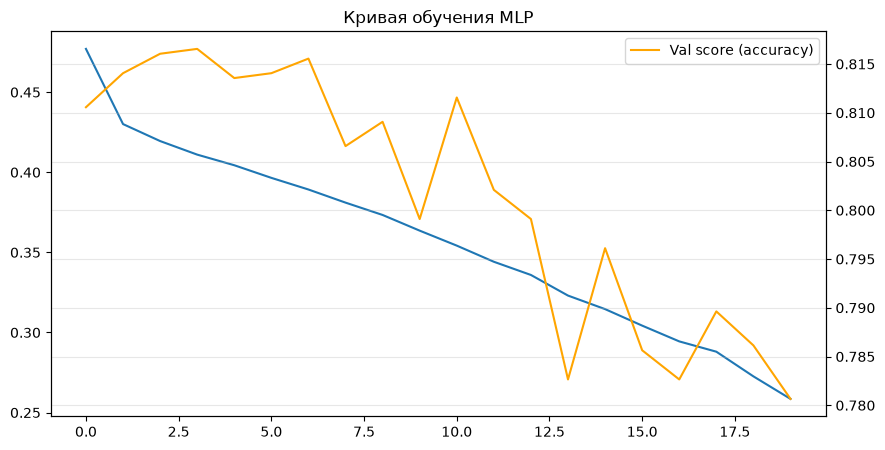

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(mlp.loss_curve_, label='Train loss')
if hasattr(mlp, 'validation_scores_'):
    plt.twinx()
    plt.plot(mlp.validation_scores_, color='orange', label='Val score (accuracy)')
plt.title('Кривая обучения MLP')
plt.xlabel('Итерация')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

In [8]:
y_proba = mlp.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

roc = roc_auc_score(y_test, y_proba)
pr = average_precision_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)

print(f'ROC-AUC: {roc:.4f}')
print(f'PR-AUC:  {pr:.4f}')
print(f'Accuracy: {acc:.4f}')
print(f'Precision_1/Recall_1/F1_1: {precision_score(y_test, y_pred):.4f} / '
      f'{recall_score(y_test, y_pred):.4f} / {f1_score(y_test, y_pred):.4f}')
print(f'Precision_0/Recall_0/F1_0: {precision_score(y_test, y_pred, pos_label=0):.4f} / '
      f'{recall_score(y_test, y_pred, pos_label=0):.4f} / {f1_score(y_test, y_pred, pos_label=0):.4f}')

ROC-AUC: 0.8239
PR-AUC:  0.9021
Accuracy: 0.8089
Precision_1/Recall_1/F1_1: 0.8211 / 0.9338 / 0.8738
Precision_0/Recall_0/F1_0: 0.7586 / 0.5055 / 0.6067


In [9]:
threshold_results = []
for th in [0.3, 0.4, 0.5, 0.6, 0.7]:
    yp = (y_proba >= th).astype(int)
    threshold_results.append({
        'Threshold': th,
        'Accuracy': accuracy_score(y_test, yp),
        'Precision_1': precision_score(y_test, yp),
        'Recall_1': recall_score(y_test, yp),
        'F1_1': f1_score(y_test, yp),
        'Precision_0': precision_score(y_test, yp, pos_label=0),
        'Recall_0': recall_score(y_test, yp, pos_label=0),
    })
threshold_df = pd.DataFrame(threshold_results)
print(threshold_df.round(4))

   Threshold  Accuracy  Precision_1  Recall_1    F1_1  Precision_0  Recall_0
0        0.3    0.7992       0.7889    0.9783  0.8735       0.8735    0.3639
1        0.4    0.8081       0.8051    0.9619  0.8766       0.8244    0.4342
2        0.5    0.8089       0.8211    0.9338  0.8738       0.7586    0.5055
3        0.6    0.8010       0.8403    0.8878  0.8634       0.6839    0.5900
4        0.7    0.7740       0.8638    0.8085  0.8352       0.5973    0.6901


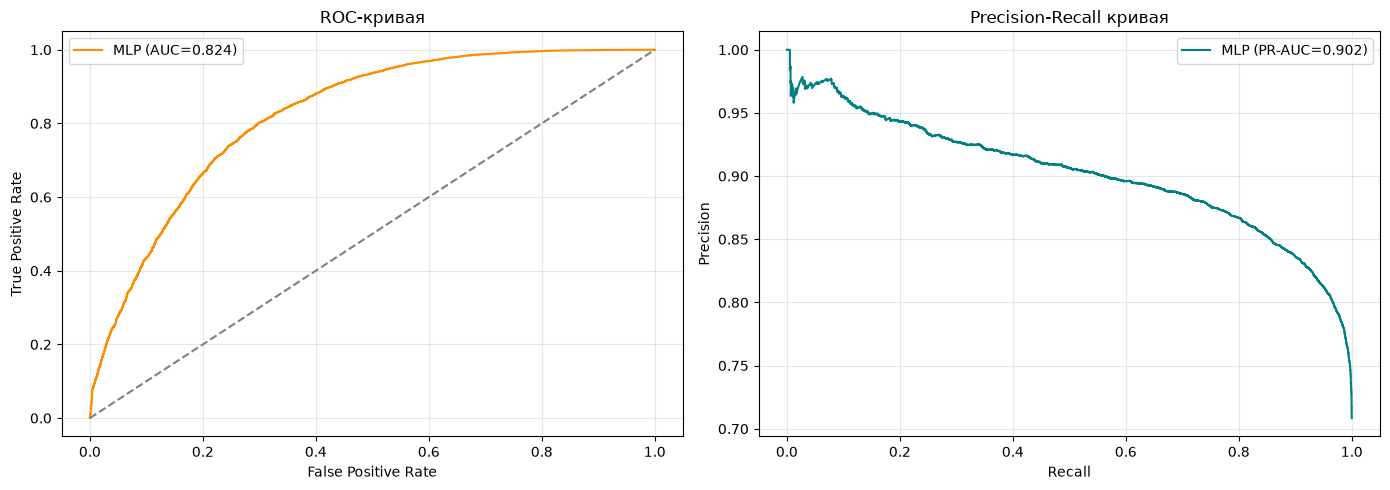

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
prec, rec, _ = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr, tpr, label=f'MLP (AUC={roc:.3f})', color='darkorange')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='grey')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC-кривая')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(rec, prec, label=f'MLP (PR-AUC={pr:.3f})', color='teal')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall кривая')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

          Model  ROC-AUC  PR-AUC
0           MLP   0.8239  0.9021
1     XGB_tuned   0.8301  0.9003
2        LogReg   0.8173  0.8923
3     XGB_SMOTE   0.8139  0.8911
4      XGB_base   0.8148  0.8891
5      LGB_base   0.8109  0.8849
6  RandomForest   0.8022  0.8792


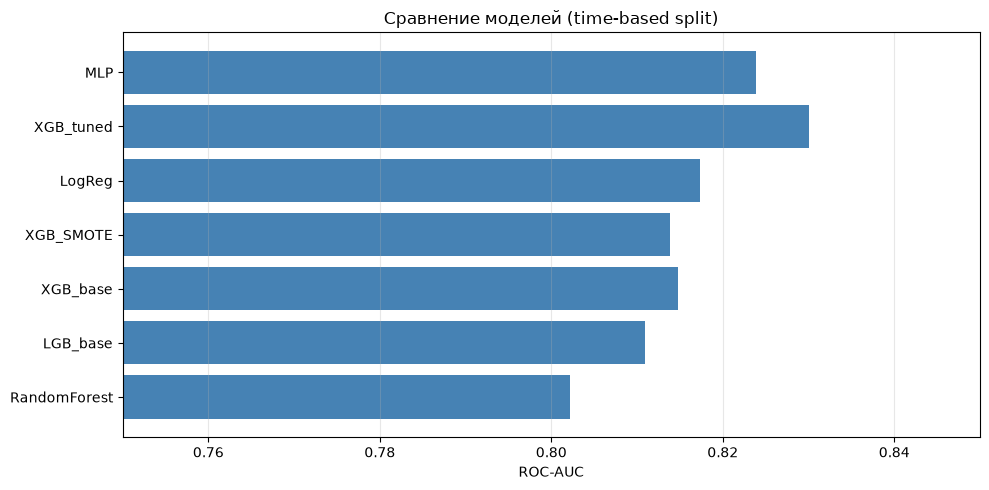

In [ ]:
# Метрики предыдущих моделей — из 03_modeling_churn_prediction.ipynb (time-based split)
results_summary = pd.DataFrame([
    {'Model': 'LogReg',       'ROC-AUC': 0.8259, 'PR-AUC': 0.9036},
    {'Model': 'RandomForest', 'ROC-AUC': 0.8103, 'PR-AUC': 0.8889},
    {'Model': 'XGB_base',     'ROC-AUC': 0.8209, 'PR-AUC': 0.9002},
    {'Model': 'LGB_base',     'ROC-AUC': 0.8201, 'PR-AUC': 0.8990},
    {'Model': 'XGB_tuned',    'ROC-AUC': 0.8341, 'PR-AUC': 0.9100},
    {'Model': 'XGB_SMOTE',    'ROC-AUC': 0.8176, 'PR-AUC': 0.9011},
    {'Model': 'MLP',          'ROC-AUC': roc,    'PR-AUC': pr},
])
results_summary = results_summary.sort_values('PR-AUC', ascending=False).reset_index(drop=True)
print(results_summary.round(4))

plt.figure(figsize=(10, 5))
plt.barh(results_summary['Model'], results_summary['ROC-AUC'], color='steelblue')
plt.xlabel('ROC-AUC')
plt.title('Сравнение моделей (time-based split)')
plt.xlim(0.75, 0.85)
plt.grid(alpha=0.3, axis='x')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()